<a href="https://colab.research.google.com/github/vuhamodala/Float-Chat-for-Indian-ocean-Data/blob/main/LSTM_4_%26_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install argopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 69.8 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: decorator
    Found existing installation: decorator 4.4.2
    Uninstalling decorator-4.4.2:
      Successfully uninstalled decorator-4.4.2
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.13.5
    Uninstalling aiohttp-3.13.5:
      Successfully uninstalled aiohttp-3.13.5
  Attempting uninstall: xarray
    Found existin

In [1]:
import pandas as pd
from argopy import DataFetcher
from concurrent.futures import ThreadPoolExecutor, as_completed
import os


In [2]:
lat_ranges = [(8,15), (15,22)]
lon_ranges = [(58,65), (65,72)]

depth_range = (0, 50)

start_date = "2019-01-01"
end_date   = "2023-12-31"

SAVE_DIR = "argo_chunks"
os.makedirs(SAVE_DIR, exist_ok=True)

In [3]:
def fetch_chunk(lat_min, lat_max, lon_min, lon_max):

    filename = f"{SAVE_DIR}/chunk_{lat_min}_{lat_max}_{lon_min}_{lon_max}.csv"

    # Skip if already exists
    if os.path.exists(filename):
        print(f"Skipping {filename}")
        return filename

    try:
        print(f"Fetching: {lat_min}-{lat_max}, {lon_min}-{lon_max}")

        region = [
            lat_min, lat_max,
            lon_min, lon_max,
            depth_range[0], depth_range[1],
            start_date, end_date
        ]

        fetcher = DataFetcher()
        ds = fetcher.region(region).to_xarray()
        df = ds.to_dataframe().reset_index()

        # Clean columns
        df.columns = df.columns.str.lower()

        df = df.rename(columns={
            'time': 'time',
            'pres': 'depth',
            'temp': 'temperature',
            'psal': 'salinity'
        })

        df = df[['time', 'depth', 'temperature', 'salinity']]

        # Basic cleaning
        df['time'] = pd.to_datetime(df['time'], errors='coerce')
        df = df.dropna()

        df = df[(df['temperature'] > -2) & (df['temperature'] < 40)]
        df = df[(df['salinity'] > 30) & (df['salinity'] < 40)]

        # Save chunk
        df.to_csv(filename, index=False)

        return filename

    except Exception as e:
        print("Error:", e)
        return None

tasks = [(lat_min, lat_max, lon_min, lon_max)
         for lat_min, lat_max in lat_ranges
         for lon_min, lon_max in lon_ranges]

files = []

with ThreadPoolExecutor(max_workers=3) as executor:
    futures = [executor.submit(fetch_chunk, *task) for task in tasks]

    for f in as_completed(futures):
        res = f.result()
        if res:
            files.append(res)


Fetching: 8-15, 58-65
Fetching: 8-15, 65-72
Fetching: 15-22, 58-65
Fetching: 15-22, 65-72


In [4]:
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("Merged Shape:", df.shape)

Merged Shape: (29653, 4)


/tmp/ipykernel_1587/3857594028.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)


In [5]:
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')

df_daily = df.groupby(pd.Grouper(key='time', freq='D')).agg({
    'temperature': ['mean', 'std'],
    'salinity': ['mean', 'std']
})

df_daily.columns = [
    'temp_mean', 'temp_std',
    'sal_mean', 'sal_std'
]

In [6]:
df_daily = df_daily.asfreq('D')
df_daily = df_daily.interpolate()
df_daily = df_daily.dropna()


In [7]:
if len(df_daily) > 2500:
    df_daily = df_daily.iloc[::2]

print("Final Rows:", len(df_daily))


Final Rows: 1823


In [8]:
df_daily.to_csv("arabian_sea_timeseries_final.csv")

print(" arabian_sea_timeseries_final.csv")

 arabian_sea_timeseries_final.csv


In [10]:
df = pd.read_csv("arabian_sea_timeseries_final.csv",
                 parse_dates=['time'],
                 index_col='time')

# Keep all 4 features
df = df[['temp_mean', 'temp_std', 'sal_mean', 'sal_std']]

print(df.head())

            temp_mean  temp_std   sal_mean   sal_std
time                                                
2019-01-03   6.555532  0.025646  35.051936  0.001725
2019-01-04   6.228830  0.022486  35.041953  0.001571
2019-01-05   5.902127  0.019325  35.031970  0.001417
2019-01-06   5.575425  0.016164  35.021987  0.001264
2019-01-07   5.248723  0.013003  35.012004  0.001110


In [11]:
split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df = df.iloc[split:]

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

In [13]:
import numpy as np

def create_sequences(data, seq_len=30, horizon=7):
    X, y = [], []

    for i in range(len(data) - seq_len - horizon):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+horizon, 0])  # temp_mean

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_test, y_test = create_sequences(test_scaled)

print(X_train.shape, y_train.shape)

(1421, 30, 4) (1421, 7)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(30, X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(7))

model.compile(optimizer='adam', loss='mae')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,311 (118.40 KB)

 Trainable params: 30,311 (118.40 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - loss: 0.1120 - val_loss: 0.0512
Epoch 2/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.0648 - val_loss: 0.0477
Epoch 3/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0561 - val_loss: 0.0467
Epoch 4/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0536 - val_loss: 0.0524
Epoch 5/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0491 - val_loss: 0.0457
Epoch 6/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0486 - val_loss: 0.0452
Epoch 7/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0474 - val_loss: 0.0453
Epoch 8/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0456 - val_loss: 0.0451
Epoch 9/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0449 - val_loss: 0.0476
Epoch 10/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.0433 - val_loss: 0.0465
Epoch 11/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0429 - val_loss: 0.0456
Epoch 12/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0

In [16]:
pred = model.predict(X_test)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step


In [17]:
temp_min = scaler.data_min_[0]
temp_max = scaler.data_max_[0]

pred_rescaled = pred * (temp_max - temp_min) + temp_min
y_test_rescaled = y_test * (temp_max - temp_min) + temp_min

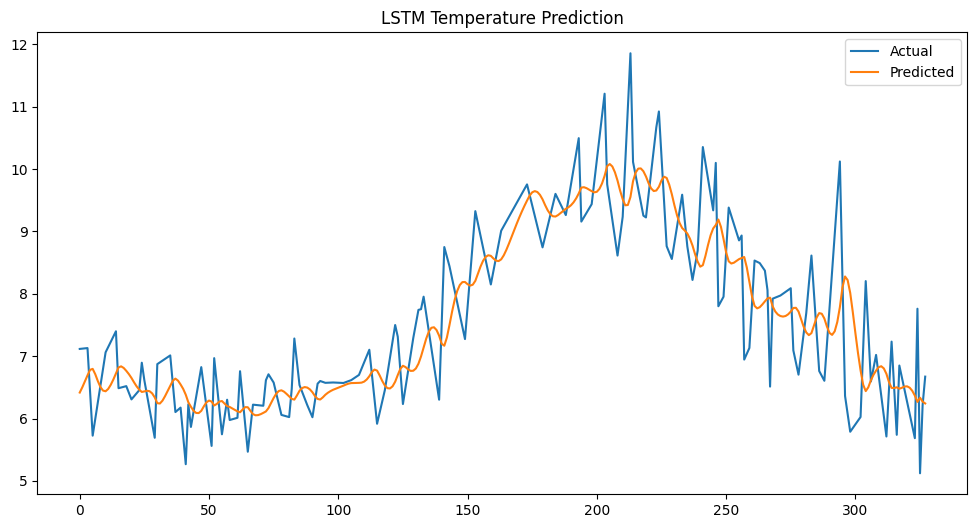

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_rescaled[:, 0], label="Actual")
plt.plot(pred_rescaled[:, 0], label="Predicted")

plt.legend()
plt.title("LSTM Temperature Prediction")
plt.show()

In [19]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [20]:
temp_min = scaler.data_min_[0]
temp_max = scaler.data_max_[0]

# Train
train_pred_rescaled = train_pred * (temp_max - temp_min) + temp_min
y_train_rescaled = y_train * (temp_max - temp_min) + temp_min

# Test
test_pred_rescaled = test_pred * (temp_max - temp_min) + temp_min
y_test_rescaled = y_test * (temp_max - temp_min) + temp_min

In [21]:
# Train
y_train_true = y_train_rescaled.flatten()
y_train_pred = train_pred_rescaled.flatten()

# Test
y_test_true = y_test_rescaled.flatten()
y_test_pred = test_pred_rescaled.flatten()

In [22]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    return mae, rmse, mape

In [23]:
# Train metrics
train_mae, train_rmse, train_mape = evaluate(y_train_true, y_train_pred)

# Test metrics
test_mae, test_rmse, test_mape = evaluate(y_test_true, y_test_pred)

In [25]:
print(" Model Evaluation\n")

print("TRAIN SET:")
print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAPE : {train_mape:.2f}%")

print("\nTEST SET:")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAPE : {test_mape:.2f}%")

 Model Evaluation

TRAIN SET:
MAE  : 0.3914
RMSE : 0.5850
MAPE : 5.12%

TEST SET:
MAE  : 0.5303
RMSE : 0.6939
MAPE : 7.02%


In [26]:
df = pd.read_csv("arabian_sea_timeseries_final.csv",
                 parse_dates=['time'],
                 index_col='time')

# Sort (very important for time series)
df = df.sort_index()

# Keep base features
df = df[['temp_mean', 'temp_std', 'sal_mean', 'sal_std']]


In [27]:
df['day_of_year'] = df.index.dayofyear
df['month'] = df.index.month

In [28]:
df['temp_trend'] = df['temp_mean'].diff()
df['sal_trend'] = df['sal_mean'].diff()

In [29]:
df = df.dropna()

In [30]:
print(df.head())
print("\nShape:", df.shape)

            temp_mean  temp_std   sal_mean   sal_std  day_of_year  month  \
time                                                                       
2019-01-04   6.228830  0.022486  35.041953  0.001571            4      1   
2019-01-05   5.902127  0.019325  35.031970  0.001417            5      1   
2019-01-06   5.575425  0.016164  35.021987  0.001264            6      1   
2019-01-07   5.248723  0.013003  35.012004  0.001110            7      1   
2019-01-08   4.922021  0.009842  35.002021  0.000956            8      1   

            temp_trend  sal_trend  
time                               
2019-01-04   -0.326702  -0.009983  
2019-01-05   -0.326702  -0.009983  
2019-01-06   -0.326702  -0.009983  
2019-01-07   -0.326702  -0.009983  
2019-01-08   -0.326702  -0.009983  

Shape: (1822, 8)


In [31]:
df.to_csv("arabian_sea_8features.csv")

In [32]:
model = Sequential()

model.add(LSTM(96, return_sequences=True, input_shape=(30, X_train.shape[2])))
model.add(Dropout(0.15))


model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.15))

model.add(LSTM(32))
model.add(Dropout(0.1))


model.add(Dense(7))

model.compile(optimizer='adam', loss='mae')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 96)         │        38,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,647 (361.90 KB)

 Trainable params: 92,647 (361.90 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [34]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - loss: 0.0811 - val_loss: 0.0476
Epoch 2/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0525 - val_loss: 0.0524
Epoch 3/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0506 - val_loss: 0.0507
Epoch 4/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0477 - val_loss: 0.0468
Epoch 5/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0462 - val_loss: 0.0575
Epoch 6/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0459 - val_loss: 0.0473
Epoch 7/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.0440 - val_loss: 0.0461
Epoch 8/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 0.0420 - val_loss: 0.0462
Epoch 9/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.0425 - val_loss: 0.0447
Epoch 10/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.0414 - val_loss: 0.0450
Epoch 11/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 0.0443 - val_loss: 0.0458
Epoch 12/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 0.0

In [35]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [36]:
temp_min = scaler.data_min_[0]
temp_max = scaler.data_max_[0]

# Train
train_pred_rescaled = train_pred * (temp_max - temp_min) + temp_min
y_train_rescaled = y_train * (temp_max - temp_min) + temp_min

# Test
test_pred_rescaled = test_pred * (temp_max - temp_min) + temp_min
y_test_rescaled = y_test * (temp_max - temp_min) + temp_min

In [38]:
y_train_true = y_train_rescaled.flatten()
y_train_pred = train_pred_rescaled.flatten()

y_test_true = y_test_rescaled.flatten()
y_test_pred = test_pred_rescaled.flatten()

In [40]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

In [41]:
train_mae, train_rmse, train_mape = evaluate(y_train_true, y_train_pred)
test_mae, test_rmse, test_mape = evaluate(y_test_true, y_test_pred)

In [42]:
print(" 8-FEATURE LSTM EVALUATION\n")

print("TRAIN SET:")
print(f"MAE  : {train_mae:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAPE : {train_mape:.2f}%")

print("\nTEST SET:")
print(f"MAE  : {test_mae:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAPE : {test_mape:.2f}%")

 8-FEATURE LSTM EVALUATION

TRAIN SET:
MAE  : 0.4185
RMSE : 0.6223
MAPE : 5.47%

TEST SET:
MAE  : 0.5118
RMSE : 0.6692
MAPE : 6.79%


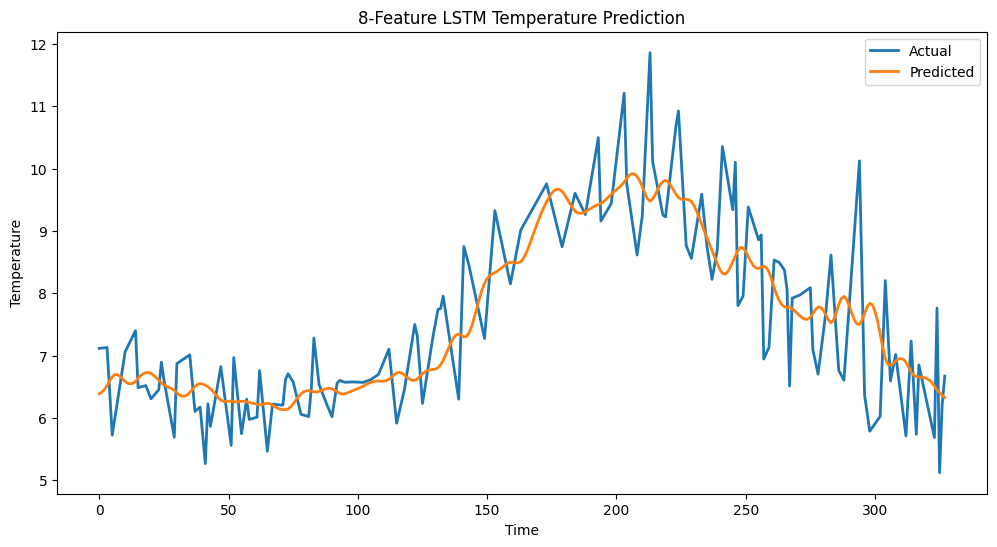

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test_rescaled[:, 0], label="Actual", linewidth=2)
plt.plot(test_pred_rescaled[:, 0], label="Predicted", linewidth=2)

plt.title("8-Feature LSTM Temperature Prediction")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()

plt.show()